# 01 — Meanline Parametric Sweep

**Purpose:** Sweep the full design space (D_tip, N, PR, ν, φ) at meanline level, evaluate aerodynamic quality constraints, and select a reference design point.

**Workflow position:** This is the first notebook. Its output — the chosen design point — is the fixed input for all subsequent notebooks.

**Design space:**

| Parameter | Range |
|---|---|
| Tip diameter D_tip | 700–1000 mm |
| Speed N | 3 000–4 000 RPM |
| Pressure ratio PR | 1.10–1.20 |
| Hub-to-tip ratio ν | 0.65–0.80 |
| Flow coefficient φ | 0.60–0.85 |

**Acceptance criteria (all must pass):**
- Blade height h ≥ 50 mm
- De Haller number DH = W₂/W₁ ≥ 0.72
- Work coefficient ψ ≤ 0.50
- Physical validity: C_θ2 < U_mean (psi < 1.0)

**References:** Dixon & Hall (2014), Ch. 3–4; Smith (1965) Smith chart.

In [6]:
"""
CELL 0  —  Repository setup  (copy this as the first cell in every notebook)
=============================================================================
Repo layout assumed:

    rotating-rig-design/          ← REPO_ROOT
    ├── src/
    │   ├── constants.py
    │   ├── igv.py
    │   ├── bellmouth.py
    │   ├── shaft.py
    │   └── plc.py
    ├── notebooks/                ← notebooks live here
    │   ├── 01_meanline.ipynb
    │   ├── 02_igv_bellmouth.ipynb
    │   ├── 03_shaft_bearings.ipynb
    │   └── 04_plc_control.ipynb
    └── README.md

Works regardless of whether the notebook is opened from:
  - notebooks/          (Jupyter server started in notebooks/)
  - rotating-rig-design/ (Jupyter server started at repo root)
  - any depth via VS Code / JupyterLab remote
"""

import sys
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.gridspec import GridSpec

# ── Repo root detection ────────────────────────────────────────────────────────
# Walk up from the notebook's directory until we find the repo root
# (identified by the presence of src/ and README.md).
# This works from any depth in the tree.

def _find_repo_root(start: Path, marker: str = "src") -> Path:
    """Walk parent directories until one contains `marker`."""
    p = start.resolve()
    for _ in range(6):                       # max 6 levels up
        if (p / marker).is_dir():
            return p
        if p.parent == p:
            break
        p = p.parent
    raise FileNotFoundError(
        f"Could not find repo root (looked for '{marker}/' "
        f"starting from {start.resolve()})"
    )

REPO_ROOT = _find_repo_root(Path())
SRC_PATH  = REPO_ROOT / "src"

# Insert src/ so modules are importable as  `from igv import ...`
# Insert repo root so  `from src.igv import ...`  also works
for p in [str(SRC_PATH), str(REPO_ROOT)]:
    if p not in sys.path:
        sys.path.insert(0, p)

# ── Module imports ─────────────────────────────────────────────────────────────
from constants import gamma, R, Cp, T0_in, P0_in

# Original parametric-sweep modules (rotor-only, no IGV pre-swirl)
from meanline import meanline_analysis, omega_from_RPM
from radial   import free_vortex

# plotting.py — optional, only needed for parametric-map notebooks
try:
    from plotting import plot_design_maps, plot_velocity_triangles, plot_radial
except Exception:
    pass

from igv import (
    igv_geometry,
    meanline_with_igv,
    print_igv_summary,
    print_rotor_summary,
)
from bellmouth import (
    bellmouth_design,
    outer_bellmouth_profile,
    centerbody_profile,
    print_bellmouth_summary,
)
from shaft import (
    rotor_mass,
    shaft_sizing,
    bearing_selection,
    campbell_data,
    print_shaft_summary,
    print_bearing_summary,
    print_campbell_summary,
)

# ── Matplotlib style ───────────────────────────────────────────────────────────
plt.rcParams.update({
    "figure.dpi":        120,
    "axes.spines.top":   False,
    "axes.spines.right": False,
    "axes.grid":         True,
    "grid.alpha":        0.3,
    "font.size":         10,
})

# Project colour palette (consistent across all notebooks)
COLORS = {
    "blue":   "#185FA5",
    "teal":   "#1D9E75",
    "coral":  "#D85A30",
    "purple": "#534AB7",
    "amber":  "#BA7517",
    "gray":   "#5F5E5A",
}

# ── Confirmation ───────────────────────────────────────────────────────────────
print(f"Repo root : {REPO_ROOT}")
print(f"Src path  : {SRC_PATH}")
print(f"Python    : {sys.version.split()[0]}")
print("Imports   : OK")

Repo root : D:\Dev\rotating-rig-design
Src path  : D:\Dev\rotating-rig-design\src
Python    : 3.10.2
Imports   : OK


## 1. Sweep parameters

In [3]:
# ── Design space ────────────────────────────────────────────────
D_tip_range = np.linspace(0.700, 1.000, 7)          # [m]
N_range     = [3000, 3500, 4000]                     # [RPM]
PR_range    = [1.10, 1.15, 1.20]
nu_target   = 0.75       # hub-to-tip ratio (fixed for primary sweep)
phi_target  = 0.725      # flow coefficient  Ca/U_mean
eta_is      = 0.85       # isentropic efficiency
h_min       = 0.050      # [m] minimum blade height

print(f'Sweep: {len(D_tip_range)} D_tip × {len(N_range)} N × {len(PR_range)} PR'
      f' = {len(D_tip_range)*len(N_range)*len(PR_range)} cases')

Sweep: 7 D_tip × 3 N × 3 PR = 63 cases


## 2. Run the sweep

In [7]:
records = []
for D in D_tip_range:
    for N in N_range:
        for PR in PR_range:
            res = meanline_analysis(D, N, PR, eta_is, nu=nu_target,
                                    phi=phi_target, h_min=h_min)
            res['valid'] = (res['physically_valid']
                            and res['h_ok']
                            and res['De_Haller'] >= 0.72
                            and res['psi'] <= 0.50)
            records.append(res)

df = pd.DataFrame(records)
df_valid = df[df['valid']].copy()

print(f'Total cases : {len(df)}')
print(f'Valid cases : {len(df_valid)}  ({100*len(df_valid)/len(df):.0f}%)')
df_valid[['D_tip_mm','N_RPM','PR','h_mm','psi','phi','De_Haller','P_shaft_kW']].round(3)

NameError: name 'pd' is not defined

## 3. Four-panel design map

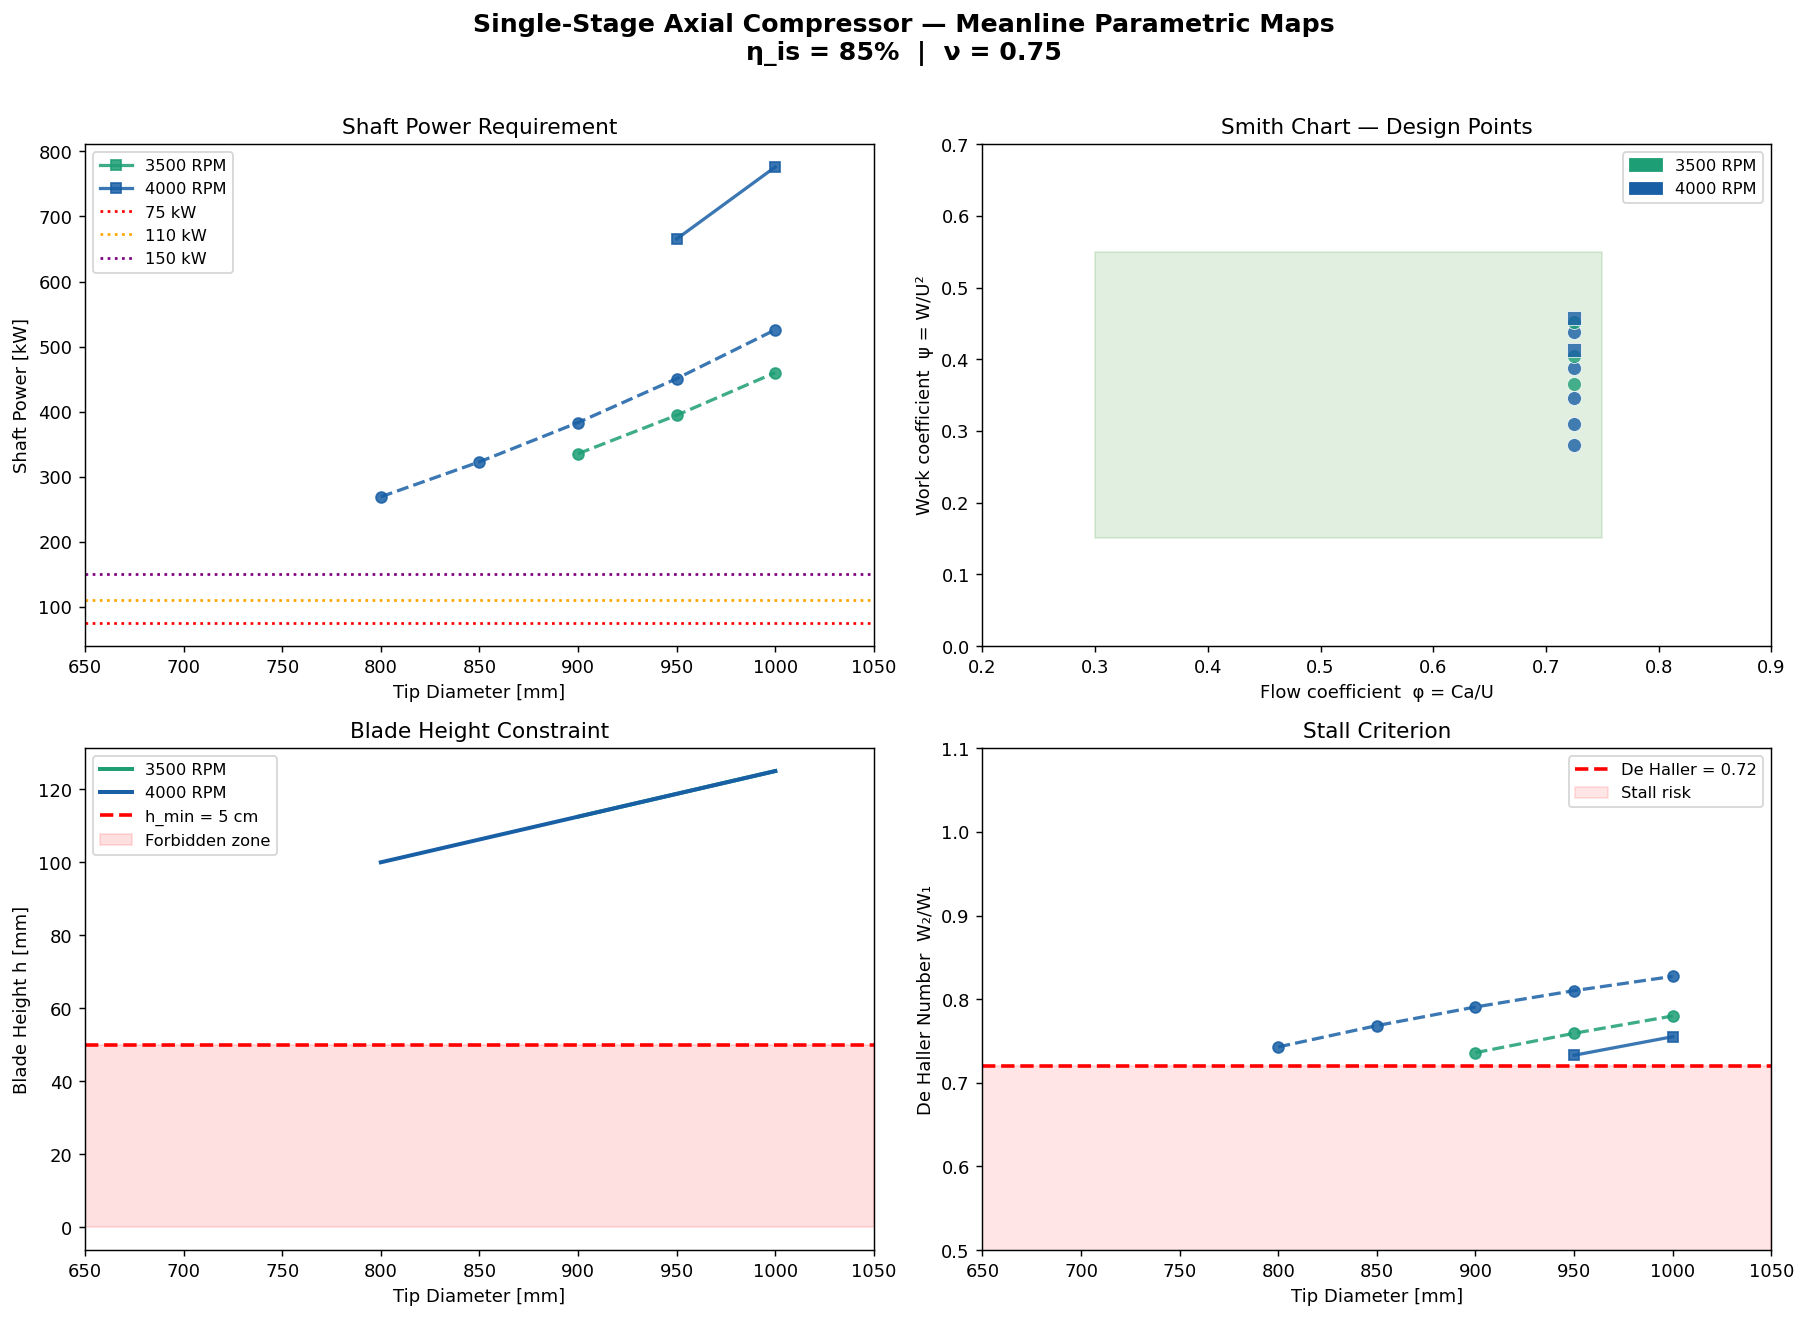

In [ ]:
plot_design_maps(df_valid, eta_is=eta_is, nu_target=nu_target, h_min=h_min,
                 save_path='../figures/01_design_maps.png')

## 4. Flow-coefficient sensitivity at fixed design point

Hold D_tip = 900 mm, N = 3500 RPM, PR = 1.10, ν = 0.75 and sweep φ to understand the sensitivity of the key loading parameters.

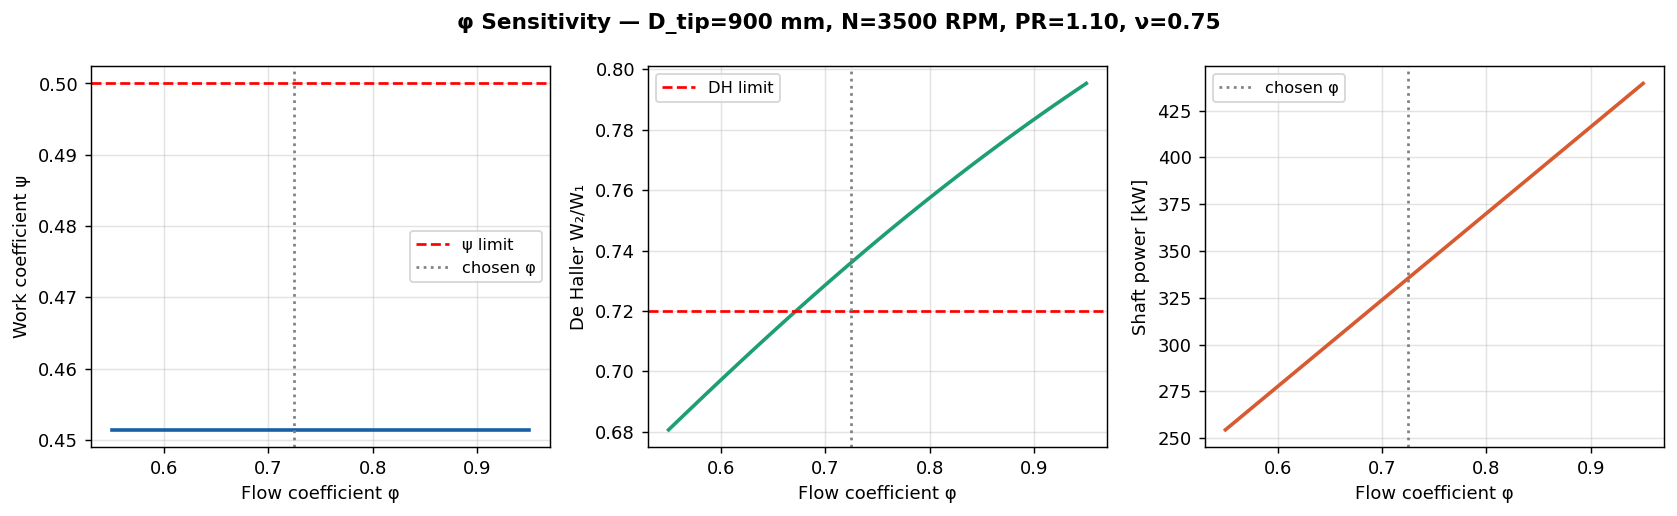

In [ ]:
phi_sweep = np.linspace(0.55, 0.95, 50)
psi_s, DH_s, P_s, Ca_s = [], [], [], []

for phi in phi_sweep:
    r = meanline_analysis(0.900, 3500, 1.10, 0.85, nu=0.75, phi=phi)
    psi_s.append(r['psi'])
    DH_s.append(r['De_Haller'])
    P_s.append(r['P_shaft_kW'])
    Ca_s.append(r['Ca'])

fig, axes = plt.subplots(1, 3, figsize=(13, 4))
fig.suptitle('φ Sensitivity — D_tip=900 mm, N=3500 RPM, PR=1.10, ν=0.75', fontweight='bold')

axes[0].plot(phi_sweep, psi_s, '#185FA5', lw=2)
axes[0].axhline(0.50, color='red', ls='--', label='ψ limit')
axes[0].axvline(0.725, color='gray', ls=':', label='chosen φ')
axes[0].set(xlabel='Flow coefficient φ', ylabel='Work coefficient ψ')
axes[0].legend(fontsize=9)

axes[1].plot(phi_sweep, DH_s, '#1D9E75', lw=2)
axes[1].axhline(0.72, color='red', ls='--', label='DH limit')
axes[1].axvline(0.725, color='gray', ls=':')
axes[1].set(xlabel='Flow coefficient φ', ylabel='De Haller W₂/W₁')
axes[1].legend(fontsize=9)

axes[2].plot(phi_sweep, P_s, '#D85A30', lw=2)
axes[2].axvline(0.725, color='gray', ls=':', label='chosen φ')
axes[2].set(xlabel='Flow coefficient φ', ylabel='Shaft power [kW]')
axes[2].legend(fontsize=9)

for ax in axes:
    ax.grid(True, alpha=0.35)
plt.tight_layout()
plt.savefig('../figures/01_phi_sensitivity.png', dpi=130, bbox_inches='tight')
plt.show()

## 5. Hub-to-tip ratio sweep

Sweep ν from 0.60 to 0.85 to confirm that blade height ≥ 50 mm and diffusion factor stays acceptable.

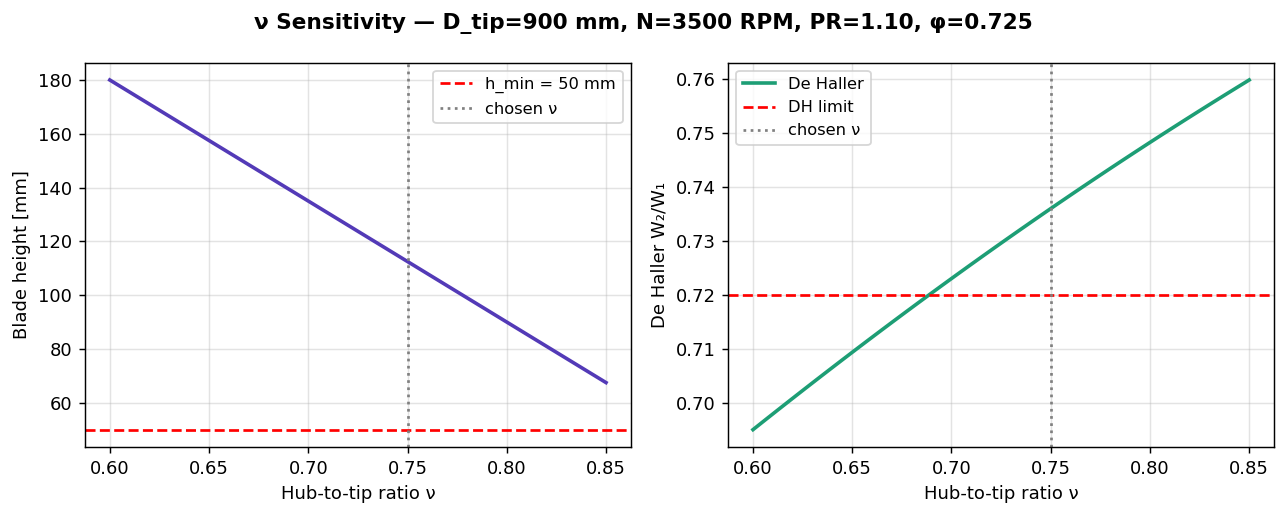

In [ ]:
nu_sweep = np.linspace(0.60, 0.85, 40)
h_s, DH_s2, psi_s2 = [], [], []

for nu in nu_sweep:
    r = meanline_analysis(0.900, 3500, 1.10, 0.85, nu=nu, phi=0.725)
    h_s.append(r['h_mm'])
    DH_s2.append(r['De_Haller'])
    psi_s2.append(r['psi'])

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
fig.suptitle('ν Sensitivity — D_tip=900 mm, N=3500 RPM, PR=1.10, φ=0.725', fontweight='bold')

axes[0].plot(nu_sweep, h_s, '#533AB7', lw=2)
axes[0].axhline(50, color='red', ls='--', label='h_min = 50 mm')
axes[0].axvline(0.75, color='gray', ls=':', label='chosen ν')
axes[0].set(xlabel='Hub-to-tip ratio ν', ylabel='Blade height [mm]')
axes[0].legend(fontsize=9); axes[0].grid(True, alpha=0.35)

axes[1].plot(nu_sweep, DH_s2, '#1D9E75', lw=2, label='De Haller')
axes[1].axhline(0.72, color='red', ls='--', label='DH limit')
axes[1].axvline(0.75, color='gray', ls=':', label='chosen ν')
axes[1].set(xlabel='Hub-to-tip ratio ν', ylabel='De Haller W₂/W₁')
axes[1].legend(fontsize=9); axes[1].grid(True, alpha=0.35)

plt.tight_layout()
plt.savefig('../figures/01_nu_sensitivity.png', dpi=130, bbox_inches='tight')
plt.show()

## 6. Reference design point — summary

From the sweep the following point offers the best balance: adequate blade height, Smith-chart position in the high-efficiency island, subcritical tip Mach number, and motor power matching standard IEC frame sizes.

In [ ]:
# ── Reference design point ──────────────────────────────────────
D_tip_ref = 0.900   # m
N_ref     = 3500    # RPM
PR_ref    = 1.10
nu_ref    = 0.75
phi_ref   = 0.725
eta_ref   = 0.85

dp = meanline_analysis(D_tip_ref, N_ref, PR_ref, eta_ref, nu=nu_ref, phi=phi_ref)

print('=' * 60)
print('  REFERENCE DESIGN POINT')
print('=' * 60)
print(f'  Tip diameter D_tip    : {dp["D_tip_mm"]:.0f} mm')
print(f'  Hub diameter D_hub    : {dp["r_hub"]*2000:.0f} mm')
print(f'  Blade height h        : {dp["h_mm"]:.1f} mm  {"✓" if dp["h_ok"] else "⚠"}')
print(f'  Hub-to-tip ratio ν    : {dp["nu"]:.3f}')
print(f'  Speed N               : {dp["N_RPM"]:.0f} RPM')
print(f'  Pressure ratio PR     : {dp["PR"]:.2f}')
print(f'  Isentropic efficiency : {dp["eta_is"]:.0%}')
print(f'  Flow coefficient φ    : {dp["phi"]:.4f}')
print(f'  Work coefficient ψ    : {dp["psi"]:.4f}  {"✓" if dp["psi"]<=0.50 else "⚠"}')
print(f'  Axial velocity Ca     : {dp["Ca"]:.2f} m/s')
print(f'  Mean blade speed U    : {dp["U_mean"]:.2f} m/s')
print(f'  Tip Mach number M_tip : {dp["M_tip"]:.4f}')
print(f'  Temperature rise ΔT₀  : {dp["delta_T0"]:.2f} K')
print(f'  Mass flow ṁ           : {dp["mdot_kg_s"]:.2f} kg/s')
print(f'  Shaft power P         : {dp["P_shaft_kW"]:.1f} kW')
print(f'  De Haller W₂/W₁      : {dp["De_Haller"]:.4f}  {"✓" if dp["De_Haller"]>=0.72 else "⚠"}')
print(f'  Rotor inlet β₁        : {dp["beta1_deg"]:.2f}°')
print(f'  Rotor exit  β₂        : {dp["beta2_deg"]:.2f}°')
print(f'  Stator inlet α₂       : {dp["alpha2_deg"]:.2f}°')
print('=' * 60)

  REFERENCE DESIGN POINT
  Tip diameter D_tip    : 900 mm
  Hub diameter D_hub    : 675 mm
  Blade height h        : 112.5 mm  ✓
  Hub-to-tip ratio ν    : 0.750
  Speed N               : 3500 RPM
  Pressure ratio PR     : 1.10
  Isentropic efficiency : 85%
  Flow coefficient φ    : 0.7250
  Work coefficient ψ    : 0.4514  ✓
  Axial velocity Ca     : 104.63 m/s
  Mean blade speed U    : 144.32 m/s
  Tip Mach number M_tip : 0.4847
  Temperature rise ΔT₀  : 9.36 K
  Mass flow ṁ           : 35.67 kg/s
  Shaft power P         : 335.4 kW
  De Haller W₂/W₁      : 0.7361  ✓
  Rotor inlet β₁        : 54.06°
  Rotor exit  β₂        : 37.11°
  Stator inlet α₂       : 31.91°


## 7. Velocity triangle at mean radius

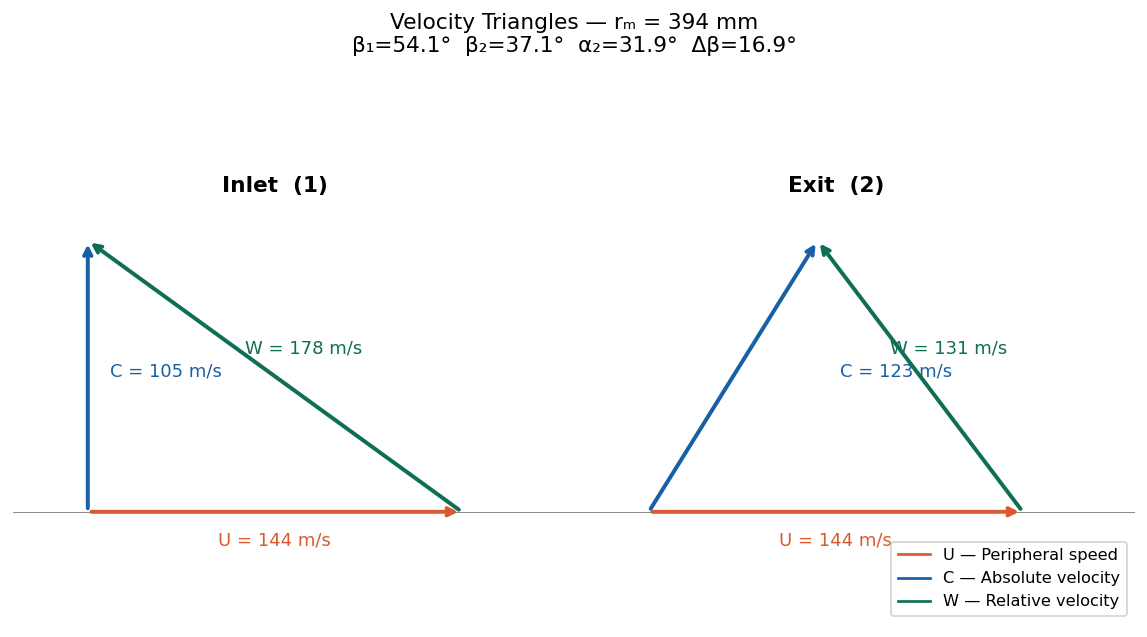

In [ ]:
from src.plotting import plot_velocity_triangles
plot_velocity_triangles(dp, save_path='../figures/01_velocity_triangles.png')

---
**Proceed to** `02_radial_distribution.ipynb` using the design point above.